# Motion energy — example analysis

Demonstrates the `aind-motion-energy` pipeline on a behavior video and aligns the
resulting trace to behavioral events (go cues) from the session NWB.

**Time reference used throughout**

| Clock | Definition |
|---|---|
| `behavior_time` | Harp / hardware acquisition seconds — what NWB stores |
| `video_time` | Seconds from first video frame (frame 0 = 0.0 s) |
| `session_time` | Seconds from first go cue (first go cue = 0.0 s) |

Run this in Code Ocean JupyterLab with the behavior data asset and
`foraging_nwb_bonsai` data asset both attached.

In [7]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import pynwb
from aind_dynamic_foraging_behavior_video_analysis.video_alignment import (
    get_first_frame_behavior_time,
    behavior_time_to_video_time,
    compute_video_session_offset,
    session_time_to_video_time,
)
from aind_motion_energy import compute_motion_energy, clean_trace, render_motion_energy_video
from aind_motion_energy.io import get_video_info

DATA_DIR    = Path("/root/capsule/data")
NWB_DIR     = DATA_DIR / "foraging_nwb_bonsai"
SCRATCH_DIR = Path("/root/capsule/scratch")
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)

VIDEO_EXTS = {".mp4", ".avi", ".mkv", ".mov", ".mj2"}

## 1. Discover data assets

In [8]:
# List behavior video files (excludes foraging_nwb_bonsai tree)
behavior_assets = [p for p in DATA_DIR.iterdir() if p.is_dir() and p.name != "foraging_nwb_bonsai"]
print("Behavior assets:", [a.name for a in behavior_assets])

videos = sorted(
    p for a in behavior_assets
    for p in a.rglob("*") if p.suffix.lower() in VIDEO_EXTS
)
for v in videos:
    info = get_video_info(v)
    print(f"  {v.relative_to(DATA_DIR)}  {info['n_frames']} frames @ {info['fps']} fps  ({info['width']}×{info['height']})")

Behavior assets: ['behavior_854151_2026-06-08_09-39-38', 'behavior_716325_2024-05-31_10-31-14']
  behavior_716325_2024-05-31_10-31-14/behavior/behavior-videos/bottom_camera.avi  2689718 frames @ 500.0 fps  (720×540)
  behavior_716325_2024-05-31_10-31-14/behavior/behavior-videos/side_camera_right.avi  2689718 frames @ 500.0 fps  (720×540)
  behavior_716325_2024-05-31_10-31-14/behavior-videos/BottomCamera/video.mp4  2689719 frames @ 500.0 fps  (720×540)
  behavior_716325_2024-05-31_10-31-14/behavior-videos/SideCameraRight/video.mp4  2689719 frames @ 500.0 fps  (720×540)
  behavior_716325_2024-05-31_10-31-14/behavior-videos/bottom_camera.avi  2689718 frames @ 500.0 fps  (720×540)
  behavior_716325_2024-05-31_10-31-14/behavior-videos/side_camera_right.avi  2689718 frames @ 500.0 fps  (720×540)
  behavior_854151_2026-06-08_09-39-38/behavior-videos/BottomCamera/video.mp4  2593965 frames @ 500.0 fps  (720×540)
  behavior_854151_2026-06-08_09-39-38/behavior-videos/SideCameraRight/video.mp4  25

## 2. Select video and find companion CSV + NWB

The companion CSV sits alongside the video and records a `Behav_Time` (Harp) timestamp
for every frame — this is what anchors the video to the behavior clock.

The NWB is located in `foraging_nwb_bonsai/` in a session folder that shares the
subject-ID and date with the behavior asset mount name (`behavior_{subject}_{date}_*`).

In [10]:
VIDEO = videos[2]    # change index to pick a different camera
print("Using video:", VIDEO.relative_to(DATA_DIR))

# Companion CSV: headerless, same folder as the video
csv_candidates = sorted(VIDEO.parent.glob("*.csv"))
if not csv_candidates:
    raise FileNotFoundError(f"No CSV found alongside {VIDEO}")
VIDEO_CSV = csv_candidates[0]
print("Companion CSV:", VIDEO_CSV.relative_to(DATA_DIR))

# Match NWB by subject ID + date extracted from the asset mount name
# e.g. "behavior_854151_2026-06-08_09-39-38" → subject="854151", date="2026-06-08"
asset_name = VIDEO.relative_to(DATA_DIR).parts[0]
m = re.match(r"behavior_(\d+)_(\d{4}-\d{2}-\d{2})", asset_name)
if not m:
    raise ValueError(f"Cannot parse subject/date from asset name: {asset_name}")
subject, date = m.group(1), m.group(2)
print(f"Subject: {subject}  Date: {date}")

nwb_candidates = sorted(NWB_DIR.rglob("*.nwb"))
nwb_candidates = [f for f in nwb_candidates if subject in f.parts[-2] and date in f.parts[-2]]
if not nwb_candidates:
    # fallback: any NWB under a folder containing subject + date anywhere
    nwb_candidates = sorted(f for f in NWB_DIR.rglob("*.nwb") if subject in str(f) and date in str(f))
if not nwb_candidates:
    raise FileNotFoundError(f"No NWB found for subject {subject} date {date} under {NWB_DIR}")
NWB_PATH = nwb_candidates[0]
print("NWB:", NWB_PATH.relative_to(DATA_DIR))

Using video: behavior_716325_2024-05-31_10-31-14/behavior-videos/BottomCamera/video.mp4
Companion CSV: behavior_716325_2024-05-31_10-31-14/behavior-videos/BottomCamera/metadata.csv
Subject: 716325  Date: 2024-05-31
NWB: foraging_nwb_bonsai/716325_2024-05-31_10-31-14.nwb


## 3. Compute motion energy

In [21]:
END_FRAME = 300000   # set to None for the full recording

me, keyframe_mask, avg_map, meta = compute_motion_energy(VIDEO, end_frame=END_FRAME)
me_clean = clean_trace(me, keyframe_mask)
fps = meta["fps"]

print(f"{meta['n_keyframes_masked']} keyframe diffs masked of {len(me)} total")
print(f"Mean ME = {me_clean.mean():.4f}")

video: 100%|██████████| 300000/300000 [09:44<00:00, 513.11frame/s]


2399 keyframe diffs masked of 299999 total
Mean ME = 0.4540


## 4. Static summary

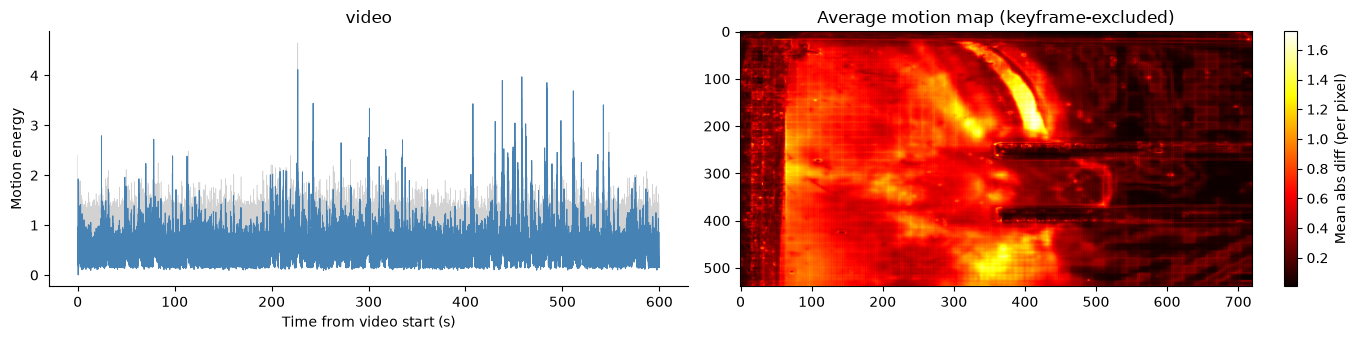

In [22]:
t = np.arange(len(me)) / fps

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

axes[0].plot(t, me,       lw=0.4, color="0.78", alpha=0.8)
axes[0].plot(t, me_clean, lw=0.7, color="steelblue")
axes[0].set_xlabel("Time from video start (s)")
axes[0].set_ylabel("Motion energy")
axes[0].set_title(VIDEO.stem)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

im = axes[1].imshow(avg_map, cmap="hot", aspect="auto")
plt.colorbar(im, ax=axes[1], label="Mean abs diff (per pixel)")
axes[1].set_title("Average motion map (keyframe-excluded)")

fig.tight_layout()
plt.show()

## 5. Load NWB and compute time alignment

`goCue_start_time` in the NWB trials table is in **behavior_time** (Harp clock).
`behavior_time_to_video_time()` subtracts the first-frame Harp timestamp (read from
the companion CSV) to convert into seconds-from-video-start.

In [23]:
io  = pynwb.NWBHDF5IO(str(NWB_PATH), "r")
nwb = io.read()

trials = nwb.trials.to_dataframe()
print("Trial columns:", trials.columns.tolist())
print(f"{len(trials)} trials total")

# Auto-detect go-cue column (name varies across sessions)
gocue_col = next(
    (c for c in trials.columns if "gocue" in c.lower() or "go_cue" in c.lower()),
    None,
)
if gocue_col is None:
    raise RuntimeError(f"No go-cue column found. Available: {trials.columns.tolist()}")
print(f"Go-cue column: '{gocue_col}'")

gocue_behavior_times = trials[gocue_col].dropna().values   # Harp seconds
print(f"First 3 go-cue behavior_times: {gocue_behavior_times[:3]}")

Trial columns: ['start_time', 'stop_time', 'animal_response', 'rewarded_historyL', 'rewarded_historyR', 'delay_start_time', 'goCue_start_time', 'reward_outcome_time', 'bait_left', 'bait_right', 'base_reward_probability_sum', 'reward_probabilityL', 'reward_probabilityR', 'reward_random_number_left', 'reward_random_number_right', 'left_valve_open_time', 'right_valve_open_time', 'block_beta', 'block_min', 'block_max', 'min_reward_each_block', 'delay_beta', 'delay_min', 'delay_max', 'delay_duration', 'ITI_beta', 'ITI_min', 'ITI_max', 'ITI_duration', 'response_duration', 'reward_consumption_duration', 'reward_delay', 'auto_waterL', 'auto_waterR', 'laser_on_trial', 'laser_wavelength', 'laser_location', 'laser_1_power', 'laser_2_power', 'laser_on_probability', 'laser_duration', 'laser_condition', 'laser_condition_probability', 'laser_start', 'laser_start_offset', 'laser_end', 'laser_end_offset', 'laser_protocol', 'laser_frequency', 'laser_rampingdown', 'laser_pulse_duration', 'session_wide_co

In [24]:
# Anchor: behavior_time of video frame 0 (from companion CSV)
first_frame_bt = get_first_frame_behavior_time(VIDEO_CSV)
print(f"First frame behavior_time: {first_frame_bt:.3f} s")

# Convert all go-cue times from behavior_time → video_time (seconds into video)
gocue_video_times = behavior_time_to_video_time(gocue_behavior_times, first_frame_bt)

# Sanity: offset used if you prefer session_time convention
first_go_cue_bt = float(gocue_behavior_times[0])
offset = compute_video_session_offset(VIDEO_CSV, first_go_cue_bt)
print(f"Session-to-video offset: {offset:.3f} s  (first go cue appears at {offset:.3f} s in the video)")

# Drop go cues outside the processed clip
gocue_video_times = gocue_video_times[gocue_video_times >= 0]
clip_duration = len(me) / fps
gocue_video_times = gocue_video_times[gocue_video_times < clip_duration]
print(f"{len(gocue_video_times)} go cues fall within the processed clip")

First frame behavior_time: 3892922.287 s
Session-to-video offset: 48.578 s  (first go cue appears at 48.578 s in the video)
46 go cues fall within the processed clip


## 6. Trial-aligned motion energy

Each row of the heatmap is a single trial; time 0 = go-cue onset.

46 complete trials


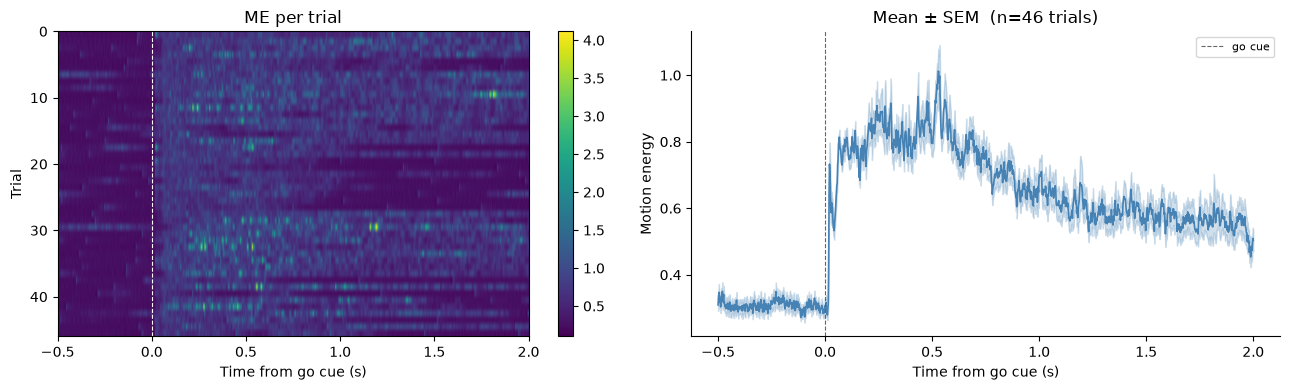

In [25]:
PRE_S  = 0.5   # seconds before go cue
POST_S = 2.0   # seconds after go cue

pre_fr  = int(PRE_S  * fps)
post_fr = int(POST_S * fps)

gocue_frames = (gocue_video_times * fps).astype(int)

aligned = []
for f0 in gocue_frames:
    s, e = f0 - pre_fr, f0 + post_fr
    if 0 <= s and e <= len(me_clean):
        aligned.append(me_clean[s:e])

if not aligned:
    print("No trials with a full window inside the clip — try a larger END_FRAME.")
else:
    aligned = np.array(aligned)
    trial_t = np.linspace(-PRE_S, POST_S, aligned.shape[1])
    print(f"{len(aligned)} complete trials")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    im = axes[0].imshow(
        aligned, aspect="auto",
        extent=[-PRE_S, POST_S, len(aligned), 0],
        cmap="viridis",
    )
    axes[0].axvline(0, color="white", lw=0.8, ls="--")
    axes[0].set_xlabel("Time from go cue (s)")
    axes[0].set_ylabel("Trial")
    axes[0].set_title("ME per trial")
    plt.colorbar(im, ax=axes[0])

    mean = aligned.mean(axis=0)
    sem  = aligned.std(axis=0) / np.sqrt(len(aligned))
    axes[1].fill_between(trial_t, mean - sem, mean + sem, alpha=0.25, color="steelblue")
    axes[1].plot(trial_t, mean, color="steelblue", lw=1.2)
    axes[1].axvline(0, color="0.4", lw=0.8, ls="--", label="go cue")
    axes[1].set_xlabel("Time from go cue (s)")
    axes[1].set_ylabel("Motion energy")
    axes[1].set_title(f"Mean ± SEM  (n={len(aligned)} trials)")
    axes[1].legend(fontsize=8)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    fig.tight_layout()
    plt.show()

## 7. Rendered example clip

Synced video + scrolling ME plot for a 4-second window around the first go cue.
Saved to `/root/capsule/scratch/`.

In [26]:
if len(gocue_frames):
    f0 = gocue_frames[0]
    clip_start = max(0, f0 - int(1.0 * fps))    # 1 s before go cue
    clip_end   = f0 + int(3.0 * fps)            # 3 s after go cue

    out_path = SCRATCH_DIR / f"{VIDEO.stem}_go_cue_example.mp4"
    render_motion_energy_video(
        VIDEO, me_clean,
        fps_source=fps,
        output_path=out_path,
        raw_trace=me,
        start_frame=clip_start,
        end_frame=clip_end,
        window_seconds=2.0,
        out_fps=120.0,
    )
    print(f"Saved: {out_path}")

Saved: /root/capsule/scratch/video_go_cue_example.mp4
